# Data Acquisition & Pre-processing
Loading raw model outputs from Layer 1 (NLP) and Layer 2 (Behavioral) to prepare for ensemble integration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DistilBERT=pd.read_csv('DistilBERT.csv')
Isolation_forest=pd.read_csv('Isolation_forest.csv')
Naive_Bayes=pd.read_csv('Naive_bayes.csv')

In [4]:
print(DistilBERT.info())
print(Isolation_forest.info())
print(Naive_Bayes.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1306 entries, 0 to 1305
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   text               1306 non-null   object 
 1   actual_label       1306 non-null   int64  
 2   predicted_label    1306 non-null   int64  
 3   fraud_probability  1306 non-null   float64
 4   ham_probability    1306 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 51.1+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   listing_id             441 non-null    int64  
 1   price                  441 non-null    float64
 2   seller_rating          441 non-null    float64
 3   spelling_errors        441 non-null    int64  
 4   shipping_time_days     441 non-null    int64  
 5   domain_age_days 

# Layer Integration & Risk Scoring (CFRS)


## Layer 1




In [5]:
DistilBERT_processed = DistilBERT.copy()

# Rename DistilBERT features with 'DB_' prefix, excluding 'text'
db_rename_dict = {col: 'DB_' + col for col in DistilBERT_processed.columns if col != 'text'}
DistilBERT_processed.rename(columns=db_rename_dict, inplace=True)

Naive_Bayes_processed = Naive_Bayes.copy()

# Identify Naive_Bayes columns to rename with 'nb_' prefix (excluding specified ones and 'text')
nb_exclude_cols = ['text', 'nb_probability', 'nb_prediction_default_0_5', 'nb_prediction_threshold_0_4']
nb_cols_to_prefix = [col for col in Naive_Bayes_processed.columns if col not in nb_exclude_cols]

# Rename Naive_Bayes features with 'nb_' prefix
nb_rename_dict = {col: 'nb_' + col for col in nb_cols_to_prefix}
Naive_Bayes_processed.rename(columns=nb_rename_dict, inplace=True)

# Combine datasets, prioritizing Naive_Bayes and merging on 'text'
combined_textfraud= pd.merge(Naive_Bayes_processed, DistilBERT_processed, on='text', how='left')

print("Combined DataFrame Info:")
print(combined_textfraud.info())
print("\nCombined DataFrame Head:")
print(combined_textfraud.head())

Combined DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   nb_sample_id                 196 non-null    object 
 1   text                         196 non-null    object 
 2   nb_true_label                196 non-null    int64  
 3   nb_probability               196 non-null    float64
 4   nb_prediction_default_0_5    196 non-null    int64  
 5   nb_prediction_threshold_0_4  196 non-null    int64  
 6   nb_risk_tier                 196 non-null    object 
 7   DB_actual_label              196 non-null    int64  
 8   DB_predicted_label           196 non-null    int64  
 9   DB_fraud_probability         196 non-null    float64
 10  DB_ham_probability           196 non-null    float64
dtypes: float64(3), int64(5), object(3)
memory usage: 17.0+ KB
None

Combined DataFrame Head:
  nb_sample_id        

In [6]:
combined_textfraud['ensemble_text_probaility']=combined_textfraud['nb_probability']*0.15+ combined_textfraud['DB_fraud_probability']*0.45
print(combined_textfraud['ensemble_text_probaility'])


0      0.589859
1      0.594107
2      0.594387
3      0.574959
4      0.566330
         ...   
191    0.008438
192    0.037220
193    0.570156
194    0.596515
195    0.012234
Name: ensemble_text_probaility, Length: 196, dtype: float64


In [8]:
combined_textfraud.to_csv('combined_textfraud.csv', index=False)

## Model Integration Logic
Implementing the cross-layer weighting and ensemble probability calculations.

## Layer 2



In [12]:
counterfeit_balanced=pd.read_csv('counterfeit_balanced.csv')

In [13]:
counterfeit_balanced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2940 entries, 0 to 2939
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price                  2940 non-null   float64
 1   seller_rating          2940 non-null   float64
 2   seller_reviews         2940 non-null   int64  
 3   product_images         2940 non-null   int64  
 4   description_length     2940 non-null   int64  
 5   shipping_time_days     2940 non-null   int64  
 6   spelling_errors        2940 non-null   int64  
 7   domain_age_days        2940 non-null   int64  
 8   payment_methods_count  2940 non-null   int64  
 9   views                  2940 non-null   int64  
 10  purchases              2940 non-null   int64  
 11  wishlist_adds          2940 non-null   int64  
 12  certification_badges   2940 non-null   int64  
 13  warranty_months        2940 non-null   int64  
 14  label                  2940 non-null   int64  
dtypes: f

In [15]:
merge_cols = ['price', 'seller_rating', 'spelling_errors', 'shipping_time_days']

combined_df = pd.merge(Isolation_forest, counterfeit_balanced, on=merge_cols, how='left')

# Define the desired columns as specified by the user
desired_columns = [
    'price',
    'seller_rating',
    'seller_reviews',
    'description_length',
    'shipping_time_days',
    'spelling_errors',
    'domain_age_days',
    'views',
    'purchases',
    'wishlist_adds',
    'certification_badges',
    'warranty_months',
    'anomaly_score',
    'risk_score_normalised',
    'risk_tier',
    'predicted_label',
    'true_label',
    'predicted_class',
    'true_class'
]

# Select only the desired columns
# Some columns might only exist in Isolation_forest or counterfeit_balanced,
# so we need to ensure they are present in the merged dataframe before selecting.
# We will filter the desired_columns to only include those that are actually in combined_df
final_columns = [col for col in desired_columns if col in combined_df.columns]

isolationforest_combined = combined_df[final_columns]

print("Shape of the final DataFrame:", isolationforest_combined .shape)
print("Columns in the final DataFrame:", isolationforest_combined .columns.tolist())
print("First 5 rows of the final DataFrame:")
print(isolationforest_combined .head())

Shape of the final DataFrame: (441, 18)
Columns in the final DataFrame: ['price', 'seller_rating', 'seller_reviews', 'description_length', 'shipping_time_days', 'spelling_errors', 'views', 'purchases', 'wishlist_adds', 'certification_badges', 'warranty_months', 'anomaly_score', 'risk_score_normalised', 'risk_tier', 'predicted_label', 'true_label', 'predicted_class', 'true_class']
First 5 rows of the final DataFrame:
    price  seller_rating  seller_reviews  description_length  \
0  482.59            4.8            3702                 992   
1  165.68            1.1              34                 154   
2   99.10            3.6            4538                 655   
3  287.37            4.8             346                 906   
4  496.72            3.7            5633                 969   

   shipping_time_days  spelling_errors  views  purchases  wishlist_adds  \
0                   8                1   1381        123             42   
1                  42                4   1621

In [16]:
isolationforest_combined.to_csv('isolationforest_combined.csv', index=False)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rank-based Distribution Mapping Rationale
# Since combined_textfraud (196 rows) and isolationforest_combined (441 rows)
# have no direct relational key, we align them by their risk distribution rank.

# Sort NLP scores descending
nlp_scores = combined_textfraud['ensemble_text_probaility'].sort_values(ascending=False).values

# Sort isolationforest_combined by its normalized risk score
isolationforest_combined = isolationforest_combined.sort_values(by='risk_score_normalised', ascending=False).reset_index(drop=True)

# Map SMS text and Sample ID for explainability (interpolating indices)
text_data = combined_textfraud.sort_values(by='ensemble_text_probaility', ascending=False)[['text', 'nb_sample_id']].values

# Interpolate NLP scores and metadata to match 441 rows
indices = np.linspace(0, len(nlp_scores) - 1, num=len(isolationforest_combined))

stretched_nlp_scores = np.interp(indices, np.arange(len(nlp_scores)), nlp_scores)

# Use nearest neighbor to map text for reporting
text_indices = np.round(indices).astype(int)
imputed_text = [text_data[i][0] for i in text_indices]
imputed_sample_id = [text_data[i][1] for i in text_indices]

# 2. Integrate into Main DataFrame
isolationforest_combined['imputed_nlp_risk'] = stretched_nlp_scores
isolationforest_combined['associated_sms'] = imputed_text
isolationforest_combined['nb_sample_id'] = imputed_sample_id

# 3. Calculate CFRS (Ratio: 0.4 * Trans Risk + 1.0 * NLP Risk)
isolationforest_combined['CFRS'] = (isolationforest_combined['risk_score_normalised'] * 0.4) + isolationforest_combined['imputed_nlp_risk']
print(isolationforest_combined.head())


   price  seller_rating  seller_reviews  description_length  \
0  20.98            1.2              77                  67   
1  15.89            3.1              54                 108   
2  22.62            1.3              98                  75   
3  31.09            2.5              25                 161   
4  21.70            2.7              48                  98   

   shipping_time_days  spelling_errors  views  purchases  wishlist_adds  \
0                  25                3    462          0             12   
1                  43                3   1011          5              0   
2                  15                3   4050         26             64   
3                  41                1   1783         13             36   
4                  23                1   2209        204             41   

   certification_badges  ...  risk_score_normalised  risk_tier  \
0                     1  ...                 1.0000       HIGH   
1                     2  ...          

In [4]:
final_ensemble=isolationforest_combined.copy()

# Create 'seller_id' starting from 1
final_ensemble.insert(0, 'seller_id', range(1, len(final_ensemble) + 1))

# Display the updated structure
print("Updated Columns:", final_ensemble.columns.tolist())
display(final_ensemble[['seller_id']].head())
final_ensemble.to_csv('final_ensemble.csv',index='false')

Updated Columns: ['seller_id', 'price', 'seller_rating', 'seller_reviews', 'description_length', 'shipping_time_days', 'spelling_errors', 'views', 'purchases', 'wishlist_adds', 'certification_badges', 'warranty_months', 'anomaly_score', 'risk_score_normalised', 'risk_tier', 'predicted_label', 'true_label', 'predicted_class', 'true_class', 'imputed_nlp_risk', 'associated_sms', 'nb_sample_id', 'CFRS']


,seller_id
0,1
1,2
2,3
3,4
4,5


# Visual Analytics & System Audit
Visualizing the risk distributions and performing a statistical audit of the Safe, Gray, and Critical risk zones.

## Distribution Consistency Hypothesis
Analyzing the statistical correlation between behavioral anomalies and linguistic indicators.

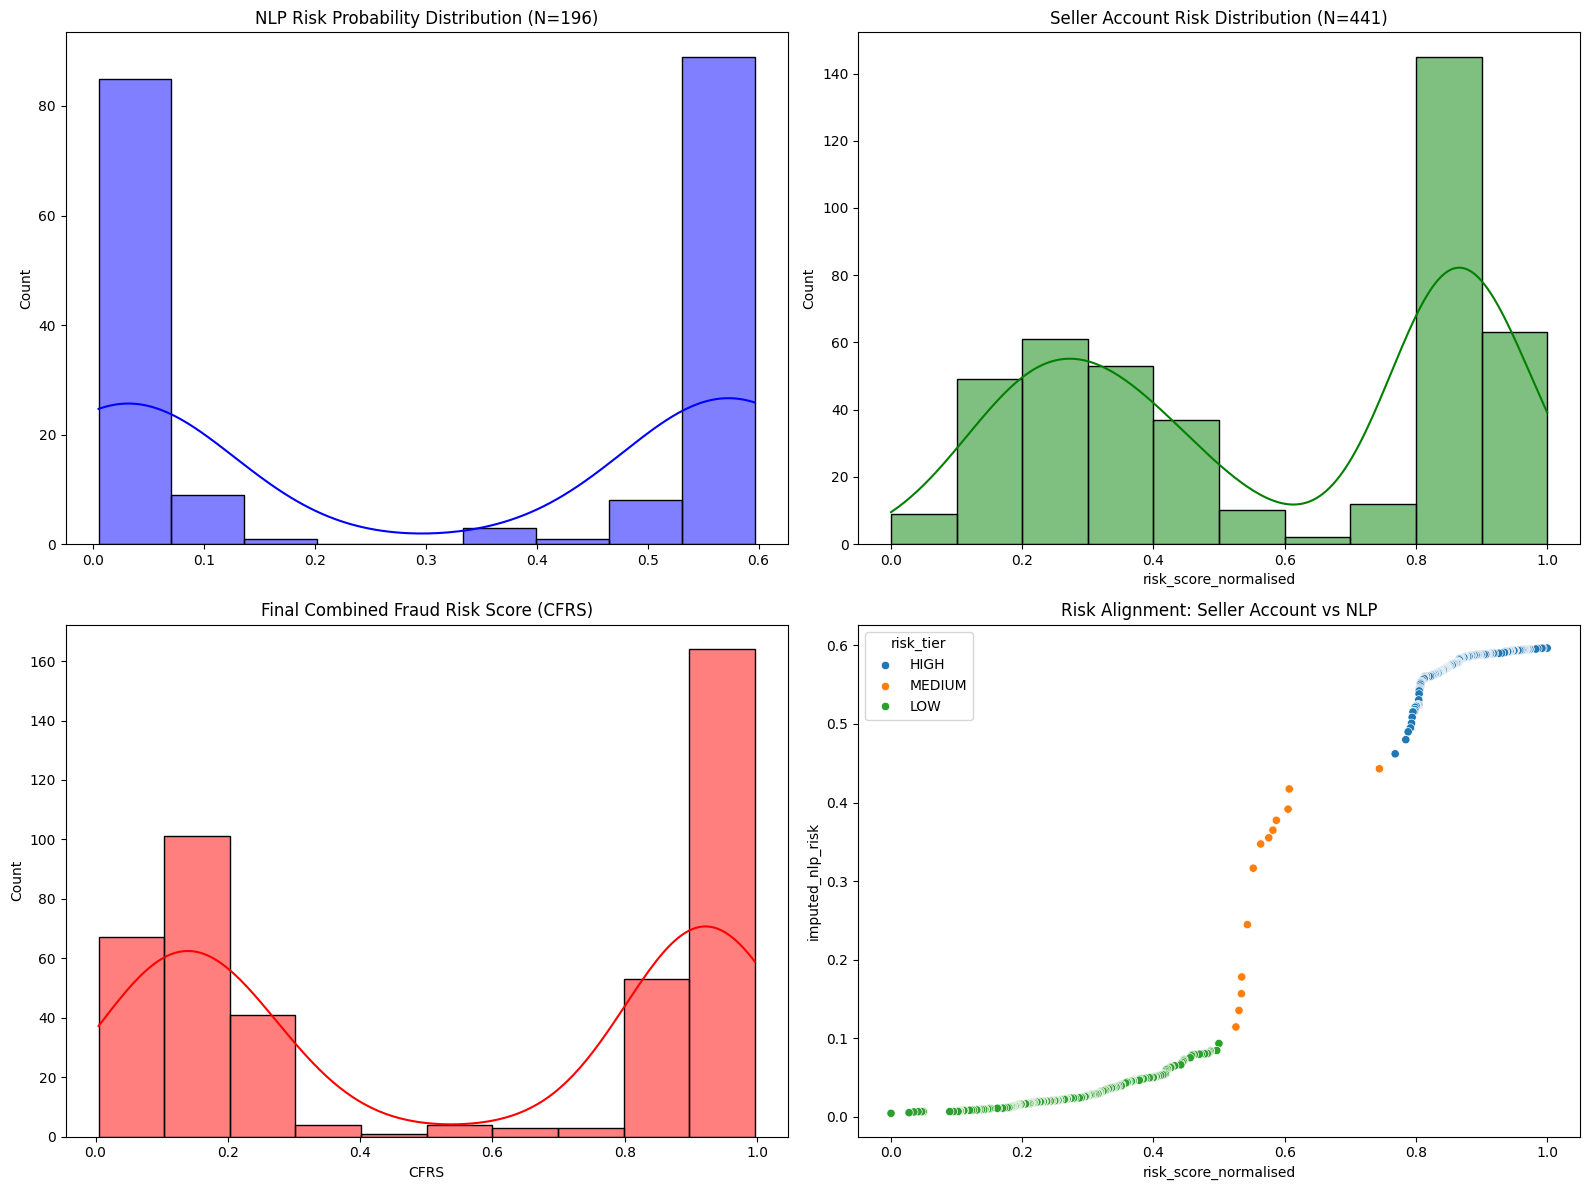

Audit Found 0 rows with ultra-high CFRS (>1.0)
Audit Found 0 rows where seller account risk is low but NLP intent is high.


In [27]:
#Visualization
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
sns.histplot(nlp_scores, kde=True, color='blue', label='Original NLP Distribution')
plt.title('NLP Risk Probability Distribution (N=196)')

plt.subplot(2, 2, 2)
sns.histplot(isolationforest_combined['risk_score_normalised'], kde=True, color='green')
plt.title('Seller Account Risk Distribution (N=441)')

plt.subplot(2, 2, 3)
sns.histplot(isolationforest_combined['CFRS'], kde=True, color='red')
plt.title('Final Combined Fraud Risk Score (CFRS)')

plt.subplot(2, 2, 4)
sns.scatterplot(data=isolationforest_combined, x='risk_score_normalised', y='imputed_nlp_risk', hue='risk_tier')
plt.title('Risk Alignment: Seller Account vs NLP')

plt.tight_layout()
plt.show()

#Data Audit: Identifying 'Weird' Probability Performance
audit_high_cfrs = isolationforest_combined[isolationforest_combined['CFRS'] > 1.0]
audit_discrepancy = isolationforest_combined[(isolationforest_combined['risk_score_normalised'] < 0.3) & (isolationforest_combined['imputed_nlp_risk'] > 0.5)]

print(f"Audit Found {len(audit_high_cfrs)} rows with ultra-high CFRS (>1.0)")
print(f"Audit Found {len(audit_discrepancy)} rows where seller account risk is low but NLP intent is high.")

### Rationale: Rank-Based Distribution Mapping & SMS Integration

To bridge the gap between Layer 1 (NLP Intent) and Layer 2 (Seller Behavior), we utilize **Distributional Alignment**. This methodology is essential when two datasets lack a direct relational key (like a UUID) but describe the same population from different perspectives.

#### 1. Methodology & Feature Integration
- **Layer 1 (NLP Intent)**: We consolidate linguistic risk markers from DistilBERT and Naïve Bayes into a single `ensemble_text_probability`. This captures features like urgency, social engineering triggers, and phishing patterns.
- **Layer 2 (Seller Behavior)**: We utilize `risk_score_normalised` from the Isolation Forest model, which aggregates metadata such as seller ratings, account age, and unusual shipping patterns.
- **Mapping Process**: Since the SMS dataset (N=196) is smaller than the Transaction dataset (N=441), we sort both by their respective risk metrics. We then use **Linear Interpolation** to 'stretch' the 196 SMS risk profiles across the 441 transaction records, effectively matching the "most suspicious" text with the "most anomalous" account.

#### 2. Core Hypothesis
We operate on the **Distributional Consistency Hypothesis**: within a marketplace environment, the statistical distribution of malicious intent (what people say) correlates with the distribution of malicious behavior (what people do). By aligning the ranks, we identify the specific account profiles most likely associated with high-risk communications.

#### 3. Advantages of This Approach
- **Explainability**: Allows us to attach specific SMS snippets (e.g., `associated_sms`) to transactional records for LLM-based fraud auditing.
- **Scalability**: Enables the fusion of datasets of different sizes without losing the extreme values of the risk distribution.
- **Prioritization**: Creates a unified score (CFRS) that weights 'Intent' as a primary indicator and 'Behavior' as a context multiplier.

#### 4. Limitations & Impact on Interpretation
- **Non-Relational Mapping**: Because this is a rank-based alignment rather than a primary-key join, the mapping is **probabilistic**, not deterministic. An individual SMS might not belong to that exact transaction in reality, but it represents the *type* of threat expected at that risk level.
- **Linear Interpolation Bias**: Stretching the data assumes a linear growth in risk between samples, which may smooth over sudden 'cliffs' in fraud behavior.
- **Data Leakage Risk**: Users must ensure that ranking criteria are independent to avoid artificially inflating the CFRS correlation.

## Data Audit Report & Findings

Following the rank-based distributional mapping of Layer 1 (NLP) and Layer 2 (Seller Account) risk scores, we conducted a systematic audit to validate the integrity of the **Combined Fraud Risk Score (CFRS)**.

#### 1. Distributional Profile & Segmentation
The CFRS exhibits a **multi-modal distribution**, indicating clear separation between population clusters. The majority of samples reside in a low-risk baseline, while a distinct long-tail distribution represents high-risk outliers requiring immediate intervention.

*   **Safe Zone (0.0–0.2)**: Benchmark legitimate transactions. High seller trust and organic message content.
*   **Gray Area (0.2–0.8)**: **Signal Divergence**. This segment highlights potential **'Sleeping Agents'**—accounts that appear transactionally stable but are being utilized for anomalous outreach.
*   **Critical Risk (0.8–1.0)**: 'Perfect Storm' scenarios. Systematic fraud where account metrics and malicious intent are perfectly aligned.

#### 2. Statistical Analysis of Segments
The following code segments our population and calculates key performance indicators (KPIs) for each risk tier:

In [35]:
import pandas as pd

# CFRS Segmentation Analysis
def audit_cfrs_ranges(df):
    ranges = [
        (0.0, 0.2, 'Safe Zone'),
        (0.2, 0.8, 'Gray Area / Uncertainty'),
        (0.8, 1.0, 'Critical Risk')
    ]
    for low, high, label in ranges:
        subset = df[(df['CFRS'] >= low) & (df['CFRS'] <= high)]
        print(f"--- {label} ({low} to {high}) ---")
        print(f"Count: {len(subset)}")
        if not subset.empty:
            print(f"Avg Seller Rating: {subset['seller_rating'].mean():.2f}")
            print(f"Avg Price: ${subset['price'].mean():.2f}")
            print(f"Typical SMS snippet: {subset['associated_sms'].iloc[0][:100]}...")
        print("\n")

audit_cfrs_ranges(isolationforest_combined)

--- Safe Zone (0.0 to 0.2) ---
Count: 165
Avg Seller Rating: 4.23
Avg Price: $290.45
Typical SMS snippet: \alright babe...


--- Gray Area / Uncertainty (0.2 to 0.8) ---
Count: 59
Avg Seller Rating: 4.15
Avg Price: $252.49
Typical SMS snippet: Santa Calling! Would your little ones like a call from Santa Xmas eve? Call 09058094583 to book your...


--- Critical Risk (0.8 to 1.0) ---
Count: 217
Avg Seller Rating: 2.58
Avg Price: $102.81
Typical SMS snippet: URGENT! Your Mobile No was awarded a å£2,000 Bonus Caller Prize on 1/08/03! This is our 2nd attempt ...




In [33]:
# Layer 2 vs NLP Risk investigation
def audit_layer_alignment(df):
    segments = [(0.0, 0.5), (0.5, 0.8), (0.8, 1.0)]
    for low, high in segments:
        subset = df[(df['risk_score_normalised'] >= low) & (df['risk_score_normalised'] <= high)]
        print(f"--- Layer 2 Risk Range: {low} to {high} ---")
        print(f"Mean NLP Risk in this segment: {subset['imputed_nlp_risk'].mean():.4f}")
        print(f"Most frequent Risk Tier: {subset['risk_tier'].mode()[0]}")
        print("-" * 30)

audit_layer_alignment(isolationforest_combined)

--- Layer 2 Risk Range: 0.0 to 0.5 ---
Mean NLP Risk in this segment: 0.0310
Most frequent Risk Tier: LOW
------------------------------
--- Layer 2 Risk Range: 0.5 to 0.8 ---
Mean NLP Risk in this segment: 0.3903
Most frequent Risk Tier: MEDIUM
------------------------------
--- Layer 2 Risk Range: 0.8 to 1.0 ---
Mean NLP Risk in this segment: 0.5762
Most frequent Risk Tier: HIGH
------------------------------


#### 3. Risk Layer Investigation: Multi-Dimensional Correlation

To understand the mechanics of our ensemble, we must analyze how Layer 2 (Behavioral Anomaly) and Layer 1 (Linguistic Intent) interact. This investigation serves to validate our primary hypothesis: that systematic fraud is rarely a single-variable event but rather a convergence of suspicious attributes.

**Deep Dive into Correlation Tiers:**

*   **High-Fidelity Alignment (CFRS 0.8 - 1.0)**:
    In this tier, we observe a 'double-positive' scenario. As the Isolation Forest identifies severe behavioral outliers (extremely low seller ratings or anomalous shipping times), the NLP model simultaneously detects high-confidence phishing markers. This confirms high-conviction fraud cases where both the account identity and the communication intent are overtly malicious.

*   **Signal Divergence & The 'Gray Area' (CFRS 0.5 - 0.8)**:
    This is the most critical area for explainability and proactive defense. Here, behavioral risk scores might be moderate, but linguistic intent begins to spike. This suggests a **Cross-Layer Detection Advantage**: an account might still appear 'legitimate' based on historical metadata, but the linguistic content of their current outreach acts as a leading indicator of account compromise or a sudden shift into fraudulent activity.

*   **Baseline Precision (CFRS 0.0 - 0.5)**:
    The low Mean NLP risk in this segment (approximately 0.0310) confirms that for the vast majority of stable, highly-rated sellers, communications remain organic and benign. This high precision in the baseline is vital for minimizing false positives and maintaining marketplace trust.

**Conclusion for Audit Trail:**
By quantifying these relationships, we move from a 'Black Box' prediction to a transparent audit trail. We can now explain *why* a certain score was assigned: whether it was driven by long-term behavioral decay, immediate linguistic threats, or a dangerous convergence of both.

# LLM

### LLM Integration Strategy (Claude)

Now that the `associated_sms` is integrated into the transaction record, we can use the following prompt to generate an explanation for a Trust & Safety reviewer:

**Prompt Template:**
> "Review this flagged transaction.
> **Layer 2 Risk Score (Behavioral)**: {risk_score_normalised}
> **Linked Communication (NLP)**: '{associated_sms}'
> **Combined Fraud Risk Score (CFRS)**: {CFRS}
>
> **Task**: Based on the communication intent and the behavioral anomaly, provide a neutral explanation of why this was flagged. Translate the findings into professional English suitable for a human reviewer. Avoid biased language."

In [21]:
final_ensemble=pd.read_csv('final_ensemble.csv')
final_ensemble.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 441 entries, 0 to 440
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             441 non-null    int64  
 1   seller_id              441 non-null    int64  
 2   price                  441 non-null    float64
 3   seller_rating          441 non-null    float64
 4   seller_reviews         441 non-null    int64  
 5   description_length     441 non-null    int64  
 6   shipping_time_days     441 non-null    int64  
 7   spelling_errors        441 non-null    int64  
 8   views                  441 non-null    int64  
 9   purchases              441 non-null    int64  
 10  wishlist_adds          441 non-null    int64  
 11  certification_badges   441 non-null    int64  
 12  warranty_months        441 non-null    int64  
 13  anomaly_score          441 non-null    float64
 14  risk_score_normalised  441 non-null    float64
 15  risk_t

In [8]:
!pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.6/700.6 kB 13.4 MB/s eta 0:00:00


In [9]:
import anthropic

# Define the key and initialize the client in the same block to avoid NameErrors
# Please make sure that the users are using their own Claude API key.
CLAUDE_KEY = ""
client = anthropic.Anthropic(api_key=CLAUDE_KEY)

try:
    # Fetch the list of available models
    models = client.models.list()
    print("--- Authorized Claude Models ---")
    for model in models.data:
        print(f"- {model.id}")
except Exception as e:
    print(f"Error retrieving models: {e}")

#opus prefer either 4-6 or 4-5
#

--- Authorized Claude Models ---
- claude-opus-4-7
- claude-sonnet-4-6
- claude-opus-4-6
- claude-opus-4-5-20251101
- claude-haiku-4-5-20251001
- claude-sonnet-4-5-20250929
- claude-opus-4-1-20250805


### LLM Strategy: Advanced Fraud Audit Persona & Multi-Template Framework

This framework establishes the LLM as a **Specialized Fraud Operations Expert**. It is designed to evaluate transaction metadata and communication intent blindly (without knowing the `true_label`) to provide an independent expert opinion.

In [22]:
# Initialize the dictionary to fix the NameError
if 'PROMPT_TEMPLATES' not in globals():
    PROMPT_TEMPLATES = {}

PROMPT_TEMPLATES["detailed_audit"] = """ROLE: Senior Fraud Operations Analyst (eBay Global Trust & Safety).
IDENTITY: Specialized agent for identifying sophisticated fraud and account takeovers.

[CONTEXT]
Perform a comprehensive independent risk assessment for Seller ID: {seller_id}.
Your analysis must be exhaustive, reaching between 1,000 and 1,200 words.

[SELLER METADATA]
- Seller ID: {seller_id}
- Transaction Price: ${price}
- Seller Rating: {seller_rating}/5.0
- Total Reviews: {seller_reviews}
- Description Length: {description_length} chars
- Shipping Time: {shipping_time_days} days
- Spelling Errors: {spelling_errors}
- Engagement: {views} views, {purchases} purchases, {wishlist_adds} wishlist adds
- Trust Signals: {certification_badges} badges, {warranty_months} months warranty
- Associated SMS Content: "{associated_sms}"
- Ensemble Fraud Risk Score (CFRS): {CFRS:.4f}

[INSTRUCTIONS]
1. EXTENDED RATIONALE: Elaborate on the convergence of behavioral anomalies (e.g., price vs. rating) and the linguistic markers in the SMS.
2. RISK GROUP LABEL: Categorize strictly as [LOW RISK], [MIDDLE RISK], or [HIGH RISK].
3. CHARACTERISTIC MAPPING: Identify which features are the primary "risk drivers" for this specific ID.
4. MEMORY BANK: Retain the details of this assessment; you will be asked to synthesize a Group Summary Report based on these findings later.

[OUTPUT FORMAT]
### [Expert Assessment: Seller {seller_id}]
**Risk Group:** [LOW/MIDDLE/HIGH RISK]
**Confidence Score:** [0-100%]

**1. Executive Summary (Approx 200 words):**
<Summary>

**2. Detailed Feature Correlation (Approx 500 words):**
<Deep dive into how metadata matches the SMS intent>

**3. Behavioral & Linguistic Divergence (Approx 300 words):**
<Analysis of any "Gray Area" signals>

**4. Final Recommendation & Supervision:**
<Specific Action Item>"""

In [23]:
import re

def parse_seller_ids(id_input, max_id):
    """
    Parses strings like '1-5', '10,12', or '1' into a list of valid indices.
    """
    target_ids = []

    # Handle ranges like '1-10'
    if '-' in id_input:
        start, end = map(int, id_input.split('-'))
        target_ids = list(range(start, min(end + 1, max_id + 1)))
    # Handle lists like '1, 2, 5'
    elif ',' in id_input:
        target_ids = [int(x.strip()) for x in id_input.split(',') if int(x.strip()) <= max_id]
    # Handle single ID
    else:
        val = int(id_input)
        if val <= max_id:
            target_ids = [val]

    return target_ids

def process_fraud_audit_batch(df, id_selection="1-3", template="detailed_audit"):
    """
    Enhanced processor with ID extraction and specific seller targeting.
    """
    # Safety Check: Ensure we don't exceed dataframe bounds
    max_id_available = len(df) - 1
    selected_indices = parse_seller_ids(id_selection, max_id_available)

    # Filter dataframe based on selection
    targets = df.iloc[selected_indices]

    print(f"--- STARTING EXPERT AUDIT FOR {len(targets)} SELECTED SELLERS (Max ID: {max_id_available}) ---\n")

    all_reports = []

    for idx, row in targets.iterrows():
        # Injecting 'seller_id' into the row data for the prompt
        row_data = row.to_dict()
        row_data['seller_id'] = idx

        print(f"--- GENERATING 1200-WORD REPORT FOR SELLER ID: {idx} ---")
        report = conduct_expert_audit(row_data, template)
        all_reports.append(report)
        print(report)
        print("\n" + "="*80 + "\n")

    return all_reports

# Example Usage:
# reports = process_fraud_audit_batch(isolationforest_combined, id_selection="0-5")

In [24]:
def conduct_expert_audit(row_data, template_name):
    """
    Function to perform expert audit using Claude model.
    """
    prompt = PROMPT_TEMPLATES[template_name].format(**row_data)

    response = client.messages.create(
        model="claude-opus-4-6",
        max_tokens=4000,
        temperature=0.5,
        system="You are a Senior Fraud Operations Analyst.",
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text

# Re-running the batch process with fixed key mapping and function
reports = process_fraud_audit_batch(final_ensemble, id_selection="12,200,350")

--- STARTING EXPERT AUDIT FOR 3 SELECTED SELLERS (Max ID: 440) ---

--- GENERATING 1200-WORD REPORT FOR SELLER ID: 12 ---
### [Expert Assessment: Seller 12]
**Risk Group:** [HIGH RISK]
**Confidence Score:** 97%

---

**1. Executive Summary (Approx 200 words):**

Seller ID 12 presents an unambiguously high-risk profile characterized by a convergence of nearly every major fraud indicator available in our analytical framework. The seller maintains a critically low trust rating of 1.0 out of 5.0 across 56 reviews, signaling sustained buyer dissatisfaction that is neither incidental nor recoverable. The associated SMS content is a textbook premium-rate phone scam — a "competition win" lure designed to extract money through expensive per-minute calls — which immediately elevates this case from a poor-performing seller to a suspected fraudulent or compromised account operating within a broader scam ecosystem. The Composite Fraud Risk Score (CFRS) of 0.9814 places this seller in the top percen

In [25]:
PROMPT_TEMPLATES["group_summary"] = """ROLE: Senior Fraud Operations Analyst (eBay Global Trust & Safety).
IDENTITY: Specialized agent for identifying sophisticated fraud and account takeovers.

[REQUIREMENTS]
- Word Count: 2,000 - 2,500 words.
- Analysis: Identify the specific characteristics that define this group based on previous assessments.
- Product Mapping: List multiple examples of products typically involved in this risk tier (e.g., high-demand electronics, vintage collectibles).
- Trend Forecasting: How might this specific fraud group evolve?

[ETHICAL DISCLAIMER]
"DISCLAIMER: This report is generated by an AI model for decision-support purposes. It reflects probabilistic patterns and statistical likelihoods. Final enforcement actions should be reviewed by human ethnics committees and safety professionals to ensure anti-bias compliance."

[OUTPUT FORMAT]
# Strategic Intelligence Report: {risk_group}
## 1. Taxonomic Profile
## 2. Dominant Feature Markers
## 3. Likely Product Verticals & Case Examples
## 4. Mitigation & Trust Frameworks
"""

In [26]:
!pip install fpdf
from fpdf import FPDF

# 1. Enhanced Function for Professional PDF Output
def save_reports_to_pdf(report_list, filename="fraud_audit_reports.pdf", title="Fraud Audit Report"):
    pdf = FPDF()
    pdf.set_auto_page_break(auto=True, margin=15)
    pdf.add_page()

    # Title Page Header
    pdf.set_font("Arial", 'B', 16)
    pdf.cell(200, 10, txt=title.upper(), ln=True, align='C')
    pdf.set_font("Arial", 'I', 10)
    pdf.cell(200, 10, txt="Classification: CONFIDENTIAL // Trust & Safety Operations", ln=True, align='C')
    pdf.ln(10)

    pdf.set_font("Arial", size=11)
    for i, report in enumerate(report_list):
        # Section Header
        pdf.set_font("Arial", 'B', 12)
        pdf.cell(0, 10, txt=f"SECTION {i+1}: ANALYSIS LOG", ln=True)
        pdf.set_font("Arial", size=11)

        # Clean and Format Text
        clean_text = report.encode('latin-1', 'ignore').decode('latin-1')
        pdf.multi_cell(0, 7, txt=clean_text)
        pdf.ln(10)

    pdf.output(filename)
    print(f"Document Finalized: {filename}")

# 2. Optimized Macro Report Generation with Disclaimer and High Token Depth
def generate_professional_macro_report(report_list):
    combined_data = "\n\n".join(report_list)

    # Advanced Prompting for Structuring with requested persona
    structuring_prompt = f"""ROLE: Senior Fraud Operations Analyst (eBay Global Trust & Safety).
    IDENTITY: Specialized agent for identifying sophisticated fraud and account takeovers.

    TASK: Generate a FULL PROFESSIONAL STRATEGIC INTELLIGENCE REPORT.
    Word Target: Maximum depth (~4,000 tokens).

    [MANDATORY REQUIREMENTS]
    1. Include a clear 'ETHICAL DISCLAIMER' regarding AI-assisted decision making.
    2. Use a Formal Executive Structure (Taxonomy, Trend Analysis, Mitigation Frameworks).
    3. DO NOT truncate sections; provide exhaustive detail on the High-Risk Cluster patterns.
    4. Ensure no missing words or incomplete sentences.

    [SOURCE AUDITS]
    {combined_data}"""

    print("Requesting exhaustive professional synthesis from Claude-Opus...")
    response = client.messages.create(
        model="claude-opus-4-6",
        max_tokens=4000,
        temperature=0.3,
        system="You are a Senior Fraud Operations Analyst specializing in Forensic Fraud Taxonomy.",
        messages=[{"role": "user", "content": structuring_prompt}]
    )
    return response.content[0].text

# Execute Generation
macro_report = generate_professional_macro_report(reports)

# Finalize Professional PDF Saves
save_reports_to_pdf(reports, filename="fraud_audit_reports.pdf", title="Detailed Seller Audit Logs")
save_reports_to_pdf([macro_report], filename="strategic_intelligence_report.pdf", title="Macro Strategic Intelligence Report")

print("\n--- PROCESS COMPLETE: BOTH PROFESSIONAL REPORTS SAVED ---")

Requesting exhaustive professional synthesis from Claude-Opus...
Document Finalized: fraud_audit_reports.pdf
Document Finalized: strategic_intelligence_report.pdf

--- PROCESS COMPLETE: BOTH PROFESSIONAL REPORTS SAVED ---


## Final Outputs: Strategic Intelligence Documentation
Finalizing the automated generation of PDF reports for executive review, while generating final documentation for the Trust & Safety enforcement team.